## 1. What this notebook computes

To *quantise* the field dirac16complex means to turn its 16 components $\Psi_A$
($A = 1, \dots, 16$) into operators on a space of states, with a rule for the
anticommutator $\{\Psi_A, \Psi^\dagger_C\} = \Psi_A\Psi^\dagger_C +
\Psi^\dagger_C\Psi_A$. This notebook

- derives that rule from the Lagrangian of the field (canonical quantisation with
  the time $x_4$): $\{\Psi_A(x), \Psi^\dagger_C(y)\} = B_{AC}\,\delta^7(x - y)/\cos z$
  with the matrix $B = -iC\gamma^{(x_4)}$;
- builds a *fermionic Fock space* (the quantum states of 16 fermion modes) in a few
  lines of Python, and checks on it the anticommutator and that the quantum
  equation of motion (the Heisenberg equation) gives back the classical wave
  equation of the field;
- checks the theorem that $\Psi^\dagger$ cannot be the ordinary (Hilbert) adjoint of
  $\Psi$ in a space whose inner product is positive: the state space must carry an
  indefinite inner product, a *Krein space*;
- builds the Krein-Fock realisation, with modes of negative Krein norm and a
  Krein-boosted pair, and checks the expectation-value rule of the Revision record;
- computes which matrix maps $\Psi \to M\Psi$ keep the anticommutator, and which
  conjugation of the quantised field keeps it: $\Psi \to \Gamma\Psi^{\dagger T}$
  with the chirality matrix $\Gamma$ (it reverses the mass); the map with $M = 1$
  would turn $B$ into $-B$;
- reproduces the corresponding checks of the Revision record and draws five
  teaching figures.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 10b (The canonical anticommutator forces a Krein space) is the file
`Revision/textbook/notebooks/10b_canonical_krein.ipynb` of the repository Dirac_claude.
It derives the canonical anticommutator of dirac16complex from the time derivative term
of the Lagrangian (exactly, with sympy), builds a fermionic Fock space of the 16
components in a few lines of Python and checks on it the anticommutator, the Heisenberg
equation and the theorem that the canonical conjugate cannot be the Hilbert adjoint in a
space with a positive inner product; it then builds the Krein-Fock realisation with modes
of negative Krein norm, including a Krein-boosted pair, checks the expectation-value
rule, and computes which matrix maps keep the anticommutator: the Krein signs of the
chirality, of the eight gammas and of the eight reflections, and the conjugation of the
quantised field that preserves the anticommutator (the matrix Gamma, which reverses the
mass); five teaching figures. It needs a computer with Windows 11, macOS or Linux, an
internet connection for the installation, the program Git, and Python 3.12 or newer (the
notebooks were built with Python 3.14.5) with these packages at exactly these versions:
numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
imports numpy, sympy and matplotlib; the other packages run Jupyter, the program that
shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 10b_canonical_krein.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 10b_canonical_krein.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
10b_canonical_krein.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:
`Revision/textbook/figures/10b.captions.json`,
`Revision/textbook/figures/10b_1_positivity.png`,
`Revision/textbook/figures/10b_2_krein_norms_random.png`,
`Revision/textbook/figures/10b_3_krein_plane.png`,
`Revision/textbook/figures/10b_4_expectation_rule.png` and
`Revision/textbook/figures/10b_5_krein_signs.png`. It changes no other file of the
repository; running it headless or saving it in JupyterLab also rewrites the notebook
file itself. It does not use the internet while it runs. The files it writes are the same
files that are stored in the repository (on another computer a figure may differ in a few
bytes, which is harmless). To get the stored versions back, run this command in the
repository folder (it also undoes every change you made yourself in the folder
Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 10b_5_krein_signs.png exists
    ALL 24 CHECKS PASSED (notebook 10b)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/10b_canonical_krein.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for gammas.json, pairing-theory.json or
  charge-conjugation-and-u1.json: the notebook reads three files of the repository; it
  must be opened inside the folder Revision/textbook/notebooks of a complete copy of the
  repository. Clone the repository again and open the notebook there.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 10b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 10b (The canonical anticommutator forces a Krein space) is the file
# Revision/textbook/notebooks/10b_canonical_krein.ipynb of the repository Dirac_claude.
# It derives the canonical anticommutator of dirac16complex from the time derivative term
# of the Lagrangian (exactly, with sympy), builds a fermionic Fock space of the 16
# components in a few lines of Python and checks on it the anticommutator, the Heisenberg
# equation and the theorem that the canonical conjugate cannot be the Hilbert adjoint in
# a space with a positive inner product; it then builds the Krein-Fock realisation with
# modes of negative Krein norm, including a Krein-boosted pair, checks the
# expectation-value rule, and computes which matrix maps keep the anticommutator: the
# Krein signs of the chirality, of the eight gammas and of the eight reflections, and the
# conjugation of the quantised field that preserves the anticommutator (the matrix Gamma,
# which reverses the mass); five teaching figures. It needs a computer with Windows 11,
# macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 10b_canonical_krein.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 10b_canonical_krein.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 10b_canonical_krein.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
# Revision/textbook/figures/10b.captions.json,
# Revision/textbook/figures/10b_1_positivity.png,
# Revision/textbook/figures/10b_2_krein_norms_random.png,
# Revision/textbook/figures/10b_3_krein_plane.png,
# Revision/textbook/figures/10b_4_expectation_rule.png and
# Revision/textbook/figures/10b_5_krein_signs.png. It changes no other file of the
# repository; running it headless or saving it in JupyterLab also rewrites the notebook
# file itself. It does not use the internet while it runs. The files it writes are the
# same files that are stored in the repository (on another computer a figure may differ
# in a few bytes, which is harmless). To get the stored versions back, run this command
# in the repository folder (it also undoes every change you made yourself in the folder
# Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 10b_5_krein_signs.png exists
#     ALL 24 CHECKS PASSED (notebook 10b)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/10b_canonical_krein.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for gammas.json, pairing-theory.json or
#   charge-conjugation-and-u1.json: the notebook reads three files of the repository; it
#   must be opened inside the folder Revision/textbook/notebooks of a complete copy of
#   the repository. Clone the repository again and open the notebook there.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "10b"  # this notebook: chapter 10, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 10b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **State, inner product, Hilbert space**: a quantum state is a vector; the inner
  product $\langle\phi|\psi\rangle = \sum_n \phi_n^*\psi_n$ of two states is a
  complex number, and $\langle\psi|\psi\rangle > 0$ for every state $\psi \neq 0$
  (it is *positive*). A space of states with a positive inner product is a
  *Hilbert space*. Positivity is what makes probabilities possible.
- **Operator, Hilbert adjoint**: an operator maps states to states. The Hilbert
  adjoint $X^*$ of $X$ is the operator with $\langle\phi|X\psi\rangle =
  \langle X^*\phi|\psi\rangle$ for all states; for a matrix it is the conjugate
  transpose.
- **Anticommutator**: $\{X, Y\} = XY + YX$.
- **Fermion mode, occupation, vacuum**: a fermion mode is either empty or occupied
  once (the Pauli principle). With 16 modes a basis state is a *pattern* of 16
  occupations (0 or 1); there are $2^{16} = 65536$ patterns. The *vacuum* is the
  pattern with every mode empty. The annihilation operator $f_p$ empties mode $p$
  and the creation operator $f_p^*$ fills it, with a sign explained in Section 6.
- **Fock space**: all superpositions of the patterns, with the positive inner
  product in which the patterns are orthonormal.
- **Canonical conjugate**: the operator $\Psi^\dagger_A$ that the Lagrangian pairs
  with $\Psi_A$; the question of the notebook is whether it equals the Hilbert
  adjoint $\Psi_A^*$.
- **Krein form, Krein space, fundamental symmetry**: a Krein space is a space with an
  indefinite but nondegenerate Hermitian form, here $[u, v] = u^\dagger B v$, and a
  matrix $J$ (here $J = B$) with $J^\dagger = J = J^{-1}$ such that
  $[u, Jv] = u^\dagger v$ is positive. $J$ is the *fundamental symmetry*.
- **Krein-orthonormal modes**: columns $u_n$ with $u_n^\dagger B u_m = \epsilon_n
  \delta_{nm}$, $\epsilon_n = +1$ or $-1$. A *Krein boost* mixes a mode of Krein
  norm $+1$ with one of $-1$ by the numbers $\cosh t$ and $\sinh t$; it keeps the
  Krein form but changes the ordinary length.
- **Pattern as a whole number**: the program stores a pattern as one whole number
  $n$ whose binary digit number $p$ (counted from 0) is the occupation of mode $p$;
  `n >> p & 1` reads that digit.

## 4. The physical and mathematical situation

**The time-derivative term of the Lagrangian, line by line.** The Lagrangian of
dirac16complex in the author's metric (the Revision theory record) is
$\mathcal{L} = \cos z\,\big[\frac12\sum_a f_a^{-1}(\bar\Psi\gamma^{(x_a)}\partial_a
\Psi - \partial_a\bar\Psi\gamma^{(x_a)}\Psi) - mS - U(S)\big]$ with $z = 6Hx_8$,
$\bar\Psi = \Psi^\dagger C$ and $f_4 = 1$. Its only terms with a derivative in the
time $x_4$ are

$$\tfrac12\cos z\,\big(\Psi^\dagger C\gamma^{(x_4)}\partial_4\Psi -
\partial_4\Psi^\dagger C\gamma^{(x_4)}\Psi\big).$$

The notebook checks that $C\gamma^{(x_4)} = iB$ (this is the definition
$B = -iC\gamma^{(x_4)}$ multiplied by $i$). Insert it:

$$\tfrac{i}{2}\cos z\,\big(\Psi^\dagger B\,\partial_4\Psi - \partial_4\Psi^\dagger
B\,\Psi\big).$$

Add the total derivative $\frac{i}{2}\partial_4(\cos z\,\Psi^\dagger B\Psi)$, which
does not change the field equations; since $\cos z$ does not depend on $x_4$, the
product rule gives $\frac{i}{2}\cos z(\partial_4\Psi^\dagger B\Psi +
\Psi^\dagger B\partial_4\Psi)$, and the sum is

$$i\cos z\,\Psi^\dagger B\,\partial_4\Psi = \Psi^\dagger K\,\partial_4\Psi,\qquad
K = i\cos z\,B .$$

**The rule.** For a Lagrangian of the first-order form $\Psi^\dagger K\partial_4\Psi
- \Psi^\dagger h'\Psi$ the classical equation is $K\partial_4\Psi = h'\Psi$. If the
quantum operators obey $\{\Psi_A, \Psi^\dagger_C\} = A_{AC}$ (and $\{\Psi_A,
\Psi_C\} = 0$), the operator $H = \Psi^\dagger h'\Psi$ satisfies
$[H, \Psi_c] = -(Ah'\Psi)_c$, so the Heisenberg equation $\partial_4\Psi =
i[H, \Psi]$ reads $\partial_4\Psi = -iAh'\Psi$. Agreement with the classical
equation $\partial_4\Psi = K^{-1}h'\Psi$ for every $h'$ requires $-iA = K^{-1}$,
that is $A = iK^{-1}$. With $K = i\cos z\,B$ and $B^{-1} = B$:

$$iK^{-1} = i\cdot\frac{1}{i\cos z}B^{-1} = \frac{B}{\cos z},\qquad
\{\Psi_A(x), \Psi^\dagger_C(y)\} = B_{AC}\,\frac{\delta^7(x - y)}{\cos z}.$$

(On a slice $x_4 = $ const the components at different points anticommute; the
seven-dimensional delta $\delta^7(x - y)$ expresses this. In the Fock-space
computations of this notebook one point is kept, so the anticommutator is the
matrix $B$ itself, up to the positive factor $1/\cos z$ that does not change any
sign.)

**The obstruction.** $B$ has the eigenvalue $-1$. For a column $u$ with $Bu = -u$
and $u^\dagger u = 1$, the operator $X = \sum_A u_A^*\Psi_A$ would have
$\{X, X^\dagger\} = u^\dagger Bu = -1$. If $X^\dagger$ were the Hilbert adjoint,
then for every state $\phi$ we would have $\langle\phi|\{X, X^\dagger\}|\phi\rangle =
\lVert X^\dagger\phi\rVert^2 + \lVert X\phi\rVert^2 \geq 0$, a contradiction. So the
canonical conjugate is not the Hilbert adjoint: the honest statement is that the
canonical rule defines a Krein space.

## 5. The time-derivative kernel and the canonical rule, exactly

The next cell reads the gammas, builds $C$, $B$ and the chirality $\Gamma =
\gamma^{(x_8)}\gamma^{(x_1)}\cdots\gamma^{(x_7)}$ with numpy (whole numbers and the
imaginary unit `1j`), and checks $C\gamma^{(x_4)} = iB$ and $B^{-1} = B$. Then it
repeats the rule $iK^{-1} = B/\cos z$ with sympy, keeping $\cos z$ as a positive
symbol `c`.

It also defines `check_record(condition, name, record)`, which does exactly what
`check(condition, name, record=record)` of the set-up cell does but prints the PASS
line and the line naming the reproduced Revision record in one piece (Jupyter
sends printed text to the screen in pieces whose boundaries depend on timing;
printing them in one piece keeps the stored output the same in every run).

In [2]:
import contextlib  # lets a block of code print into a text buffer
import io  # the text buffer
import sys  # the screen output, sys.stdout

import numpy as np  # numbers, arrays and matrices
import sympy as sp  # exact algebra with symbols


def check_record(condition, name, record):
    """check(condition, name, record=record), printed in one piece."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):  # what check prints goes to buffer
        check(condition, name, record=record)
    sys.stdout.write(buffer.getvalue())  # one single piece of output


fixture = json.loads(repository_file("Revision/algebra/gammas.json").read_text(
    encoding="utf-8"))
gamma = {a: np.array(fixture["gamma"][a - 1], dtype=int) for a in range(1, 9)}
C = gamma[8] @ gamma[1] @ gamma[2] @ gamma[3]  # the author's sigma16
Gamma = (gamma[8] @ gamma[1] @ gamma[2] @ gamma[3] @ gamma[4] @ gamma[5]
         @ gamma[6] @ gamma[7])  # the chirality matrix
B = -1j * (C @ gamma[4])  # B = -i C gamma^(x4)
check(np.array_equal(C @ gamma[4], 1j * B), "C gamma^(x4) = i B")
check(np.array_equal(B @ B, np.eye(16)), "B B = I, so the inverse of B is B")

c = sp.Symbol("c", positive=True)  # c stands for cos z, positive on the patch
B_exact = sp.Matrix(16, 16, lambda i, j: sp.I * int(round(B[i, j].imag)))
K = sp.I * c * B_exact  # the kernel of the time-derivative term
rule = (sp.I * K.inv()).applyfunc(sp.simplify)  # the anticommutator matrix i K^-1
check_record(rule == B_exact / c,
             "exact: i K^(-1) = B / cos z with K = i cos z B",
             record="Revision/theory/reports/wolfram-field-theory.json, check "
                    "first_order_form_and_anticommutator")

PASS C gamma^(x4) = i B
PASS B B = I, so the inverse of B is B
PASS exact: i K^(-1) = B / cos z with K = i cos z B
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    first_order_form_and_anticommutator


## 6. A fermionic Fock space in a few lines

The next cell builds the Fock space of 16 fermion modes $p = 0, 1, \dots, 15$ (mode
$p$ will carry the component $\Psi_{p+1}$). A state is stored as a Python
dictionary `{pattern: amplitude}` that lists only the patterns with a nonzero
amplitude; the vacuum is `{0: 1}` (the pattern 0 has every mode empty).

- `annihilate(p, state)` is $f_p$: in every pattern where mode $p$ is occupied it
  empties the mode; patterns where it is empty give nothing.
- `create(p, state)` is $f_p^*$: in every pattern where mode $p$ is empty it fills
  the mode.
- Both multiply by $(-1)^{\text{(number of occupied modes below } p)}$. This sign is
  what makes different modes ANTIcommute: exchanging the order in which two modes
  are filled changes the sign of the state.
- `add` forms combinations of states, `inner` is the positive inner product of two
  states, `largest` the largest size of an amplitude (to measure how far a state is
  from zero).

In [3]:
def sign_below(n, p):
    """(-1) to the power of the number of occupied modes below mode p in pattern n."""
    occupied_below = bin(n & ((1 << p) - 1)).count("1")  # count the 1-digits below p
    return -1 if occupied_below % 2 else 1


def annihilate(p, state):
    """f_p applied to a state {pattern: amplitude}."""
    result = {}
    for n, amplitude in state.items():
        if n >> p & 1:  # mode p is occupied in the pattern n
            new = n ^ (1 << p)  # the same pattern with mode p emptied
            result[new] = result.get(new, 0) + sign_below(n, p) * amplitude
    return result


def create(p, state):
    """f_p^* (the Hilbert adjoint of f_p) applied to a state."""
    result = {}
    for n, amplitude in state.items():
        if not n >> p & 1:  # mode p is empty in the pattern n
            new = n | (1 << p)  # the same pattern with mode p filled
            result[new] = result.get(new, 0) + sign_below(n, p) * amplitude
    return result


def add(*terms):
    """The state sum of coefficient * state over the pairs (coefficient, state)."""
    result = {}
    for coefficient, state in terms:
        for n, amplitude in state.items():
            result[n] = result.get(n, 0) + coefficient * amplitude
    return result


def inner(left, right):
    """The positive inner product <left|right>."""
    return sum(np.conj(a) * right.get(n, 0) for n, a in left.items())


def largest(state):
    """The largest size of an amplitude of the state (0 for the zero state)."""
    return max((abs(a) for a in state.values()), default=0.0)


VACUUM = {0: 1.0}
rng = np.random.default_rng(12345)  # random numbers with a fixed seed


def random_state(patterns=6):
    """A normalised superposition of a few random patterns."""
    state = {}
    for n in rng.integers(0, 2 ** 16, size=patterns):
        state[int(n)] = complex(rng.normal(), rng.normal())
    length = np.sqrt(inner(state, state).real)
    return {n: a / length for n, a in state.items()}


phi = random_state()
worst = 0.0
for p in range(16):
    for q in range(16):
        # {f_p, f_q^*} phi = f_p f_q^* phi + f_q^* f_p phi must be phi (p = q) or 0
        both = add((1, annihilate(p, create(q, phi))),
                   (1, create(q, annihilate(p, phi))))
        expected = phi if p == q else {}
        worst = max(worst, largest(add((1, both), (-1, expected))))
        # {f_p, f_q} phi must be 0
        pair = add((1, annihilate(p, annihilate(q, phi))),
                   (1, annihilate(q, annihilate(p, phi))))
        worst = max(worst, largest(pair))
report("largest violation of the 512 anticommutation relations", f"{worst:.1e}")
check(worst < 1e-14, "the Fock operators obey {f_p, f_q^*} = delta_pq, {f_p, f_q} = 0")

RESULT largest violation of the 512 anticommutation relations = 0.0e+00
PASS the Fock operators obey {f_p, f_q^*} = delta_pq, {f_p, f_q} = 0


## 7. The canonical field on the Fock space

In this positive Fock space the field component $\Psi_A$ is the annihilator $f_{A-1}$
and its Hilbert adjoint is $\chi_A = f_{A-1}^*$. The CANONICAL conjugate is defined as
$\Psi^\dagger = \chi B$, that is $\Psi^\dagger_A = \sum_C \chi_C B_{CA}$. Then

$$\{\Psi_A, \Psi^\dagger_C\} = \sum_D \{f_{A-1}, f_{D-1}^*\}B_{DC} = B_{AC},$$

the canonical rule of Section 5 (at one point). The next cell checks this for all
256 pairs $(A, C)$ on a random state. Then it checks the Heisenberg equation for a
plane wave: with the Hamiltonian-density matrix $h' = mC - i\sum_a k_a C\gamma^{(x_a)}$
(the matrix of $\Psi^\dagger(\ldots)\Psi$ in the Hamiltonian of a plane wave) the
operator $H = \Psi^\dagger h'\Psi = \chi(Bh')\Psi$ must satisfy $[H, \Psi_c] =
-(Bh'\Psi)_c$, and $Bh'$ must be the mode Hamiltonian $h = -im\gamma^{(x_4)} -
\gamma^{(x_4)}\sum_a k_a\gamma^{(x_a)}$. Together: $i\,\partial_4\Psi = i \cdot
i[H, \Psi] = h\Psi$, the classical wave equation of the field.

In [4]:
def psi(A, state):
    """Psi_A = f_(A-1), for the components A = 1, ..., 16."""
    return annihilate(A - 1, state)


def psi_dagger(A, state):
    """The canonical conjugate Psi^dagger_A = sum_C chi_C B_CA, chi_C = f_(C-1)^*."""
    return add(*[(B[C - 1, A - 1], create(C - 1, state))
                 for C in range(1, 17) if B[C - 1, A - 1] != 0])


worst = 0.0
for A in range(1, 17):
    for C_index in range(1, 17):
        both = add((1, psi(A, psi_dagger(C_index, phi))),
                   (1, psi_dagger(C_index, psi(A, phi))))
        worst = max(worst, largest(add((1, both), (-B[A - 1, C_index - 1], phi))))
report("largest violation of {Psi_A, Psi^dagger_C} = B_AC", f"{worst:.1e}")
check_record(worst < 1e-14, "on the Fock space {Psi_A, Psi^dagger_C} = B_AC (256 pairs)",
             record="Revision/theory/reports/python-field-theory.json, check "
                    "canonical_anticommutator_B")

m_value = 1.3  # any mass and momenta (here with momenta along the extra times too)
k = {1: 0.4, 2: -0.7, 3: 0.2, 5: 0.9, 6: -0.3, 7: 0.5, 8: 1.1}
h_prime = m_value * C - 1j * sum(k_a * (C @ gamma[a]) for a, k_a in k.items())
h_mode = -1j * m_value * gamma[4] - sum(k_a * (gamma[4] @ gamma[a])
                                         for a, k_a in k.items())
check(np.max(np.abs(B @ h_prime - h_mode)) < 1e-14, "B h' equals the mode Hamiltonian h")


def hamiltonian(state):
    """H = Psi^dagger h' Psi = sum_(C,D) (B h')_CD chi_C Psi_D applied to a state."""
    M = B @ h_prime
    return add(*[(M[c_, d_], create(c_, annihilate(d_, state)))
                 for c_ in range(16) for d_ in range(16) if abs(M[c_, d_]) > 0])


worst = 0.0
for c_ in range(16):
    commutator = add((1, hamiltonian(annihilate(c_, phi))),
                     (-1, annihilate(c_, hamiltonian(phi))))  # [H, Psi_c] phi
    expected = add(*[(-h_mode[c_, d_], annihilate(d_, phi)) for d_ in range(16)])
    worst = max(worst, largest(add((1, commutator), (-1, expected))))
report("largest violation of [H, Psi_c] = -(h Psi)_c", f"{worst:.1e}")
check_record(worst < 1e-12,
             "Heisenberg: i d4 Psi = h Psi, the classical wave equation",
             record="Revision/theory/reports/wolfram-field-theory.json, check "
                    "Heisenberg_equation_reproduces_field_equation")

RESULT largest violation of {Psi_A, Psi^dagger_C} = B_AC = 0.0e+00
PASS on the Fock space {Psi_A, Psi^dagger_C} = B_AC (256 pairs)
     reproduces Revision/theory/reports/python-field-theory.json, check
    canonical_anticommutator_B
PASS B h' equals the mode Hamiltonian h
RESULT largest violation of [H, Psi_c] = -(h Psi)_c = 1.6e-17
PASS Heisenberg: i d4 Psi = h Psi, the classical wave equation
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    Heisenberg_equation_reproduces_field_equation


## 8. The theorem: the canonical conjugate is not the Hilbert adjoint

The Revision record names an exact column with $Bu = -u$: $u_7 = -i/\sqrt2$,
$u_{16} = 1/\sqrt2$, all other entries 0. The next cell checks $Bu = -u$ and
$u^\dagger Bu = -1$ and builds three operators on the Fock space:
$X = \sum_A u_A^*\Psi_A$, its Hilbert adjoint $X^* = \sum_A u_A\chi_A$, and its
canonical conjugate $X^\dagger = \sum_A u_A\Psi^\dagger_A$. It checks
$\{X, X^*\}\phi = \phi$ (positive, as in every Hilbert space) and $\{X, X^\dagger\}
\phi = -\phi$ (the canonical value $u^\dagger Bu = -1$). So $X^\dagger = -X^*$ here:
the canonical conjugate differs from the Hilbert adjoint.

In [5]:
u = np.zeros(16, dtype=complex)
u[6] = -1j / np.sqrt(2)  # u_7 (the computer counts from 0)
u[15] = 1 / np.sqrt(2)  # u_16
krein_norm_u = (u.conj() @ B @ u).real
report("u^dagger u and u^dagger B u", f"{(u.conj() @ u).real:.12f} and "
       f"{krein_norm_u:.12f}")


def X(state):  # X = sum_A conj(u_A) Psi_A
    return add(*[(np.conj(u[A - 1]), psi(A, state)) for A in range(1, 17)])


def X_hilbert(state):  # X^* = sum_A u_A chi_A (the Hilbert adjoint of X)
    return add(*[(u[A - 1], create(A - 1, state)) for A in range(1, 17)])


def X_canonical(state):  # X^dagger = sum_A u_A Psi^dagger_A (canonical conjugate)
    return add(*[(u[A - 1], psi_dagger(A, state)) for A in range(1, 17)])


hilbert = add((1, X(X_hilbert(phi))), (1, X_hilbert(X(phi))))
canonical = add((1, X(X_canonical(phi))), (1, X_canonical(X(phi))))
hilbert_ok = largest(add((1, hilbert), (-1, phi))) < 1e-14  # {X, X^*} = +1
canonical_ok = largest(add((1, canonical), (1, phi))) < 1e-14  # {X, X^dagger} = -1
check_record(np.max(np.abs(B @ u + u)) < 1e-15 and abs(krein_norm_u + 1) < 1e-15
             and hilbert_ok and canonical_ok,
             "B u = -u: {X, X^*} = +1 but the canonical {X, X^dagger} = -1",
             record="Revision/theory/reports/wolfram-field-theory.json, check "
                    "no_positive_inner_product")

RESULT u^dagger u and u^dagger B u = 1.000000000000 and -1.000000000000
PASS B u = -u: {X, X^*} = +1 but the canonical {X, X^dagger} = -1
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    no_positive_inner_product


The next cell makes the positivity visible. For 300 random normalised states $\phi$
it computes the two lengths $\lVert X\phi\rVert^2$ and $\lVert X^*\phi\rVert^2$.
Each is a squared length, never negative, and their sum is $\langle\phi|\{X,X^*\}|
\phi\rangle = 1$: every point lies on the line $x + y = 1$ in the positive quarter
of the plane. The canonical rule would need the sum $-1$ instead (the dashed line),
which no state of any Hilbert space can reach. The same cell also shows how
indefinite the Krein form is: for 5000 random unit columns $v$ (normal random
numbers, then divided by the length) the ordinary length is always 1, but the
Krein norm $v^\dagger Bv$ is spread between $-1$ and $1$.

RESULT smallest and largest |X phi|^2 + |X^* phi|^2 = 1.000000000000 and 1.000000000000
PASS positivity: |X phi|^2 + |X^* phi|^2 = 1 for every random state
RESULT smallest and largest Krein norm of the 5000 unit columns = -0.777 and 0.704
PASS random unit columns have Krein norms of both signs, all between -1 and 1


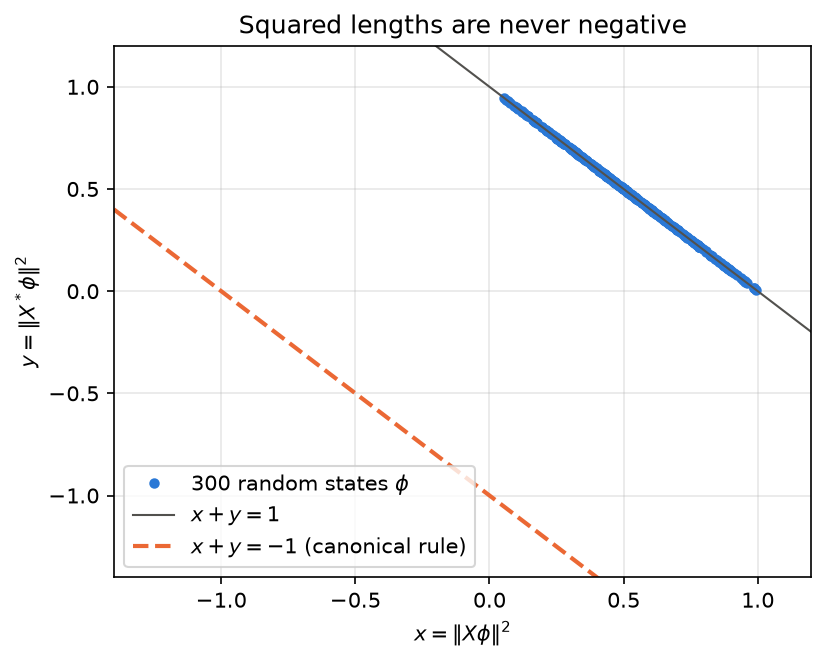

Figure 10b.1 saved as Revision/textbook/figures/10b_1_positivity.png


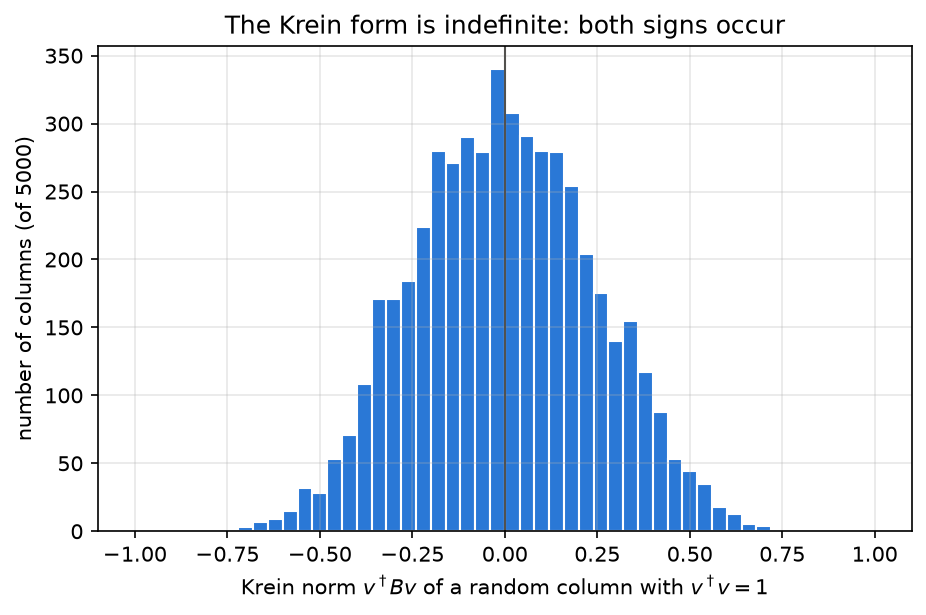

Figure 10b.2 saved as Revision/textbook/figures/10b_2_krein_norms_random.png


In [6]:
lengths = []
for _ in range(300):
    state = random_state(patterns=4)
    x_part, x_star_part = X(state), X_hilbert(state)
    lengths.append((inner(x_part, x_part).real, inner(x_star_part, x_star_part).real))
lengths = np.array(lengths)
sums = lengths.sum(axis=1)
report("smallest and largest |X phi|^2 + |X^* phi|^2",
       f"{sums.min():.12f} and {sums.max():.12f}")
check(np.all(lengths >= 0) and np.max(np.abs(sums - 1)) < 1e-12,
      "positivity: |X phi|^2 + |X^* phi|^2 = 1 for every random state")

columns = rng.normal(size=(5000, 16)) + 1j * rng.normal(size=(5000, 16))
columns = columns / np.linalg.norm(columns, axis=1, keepdims=True)  # unit length
krein_norms = np.einsum("ni,ij,nj->n", columns.conj(), B, columns).real
report("smallest and largest Krein norm of the 5000 unit columns",
       f"{krein_norms.min():.3f} and {krein_norms.max():.3f}")
check(krein_norms.min() < -0.5 and krein_norms.max() > 0.5
      and np.all(np.abs(krein_norms) <= 1 + 1e-12),
      "random unit columns have Krein norms of both signs, all between -1 and 1")

fig, ax = plt.subplots(figsize=(6.0, 4.6))
ax.plot(lengths[:, 0], lengths[:, 1], "o", color="#2a78d6", markersize=4,
        label="300 random states $\\phi$")
line = np.linspace(-1.4, 1.2, 2)
ax.plot(line, 1 - line, color="#52514e", linewidth=1, label="$x + y = 1$")
ax.plot(line, -1 - line, "--", color="#eb6834", linewidth=2,
        label="$x + y = -1$ (canonical rule)")
ax.set_xlim(-1.4, 1.2)
ax.set_ylim(-1.4, 1.2)
ax.set_xlabel("$x = \\|X\\phi\\|^2$")
ax.set_ylabel("$y = \\|X^*\\phi\\|^2$")
ax.set_title("Squared lengths are never negative")
ax.legend(loc="lower left")
save_figure(fig, "positivity",
            "For 300 random states $\\phi$ of the Fock space (blue dots): the "
            "squared length of $X\\phi$ (horizontal axis) and of $X^{\\ast}\\phi$ "
            "(vertical axis), where $X = \\sum_A \\bar{u}_A\\Psi_A$ with the "
            "recorded column $Bu = -u$ and $X^{\\ast}$ is its Hilbert adjoint; both "
            "axes are pure numbers. Every dot lies on the grey line $x + y = 1$ in "
            "the quarter where both are positive, because $\\|X\\phi\\|^2 + "
            "\\|X^{\\ast}\\phi\\|^2 = \\langle\\phi|\\{X, X^{\\ast}\\}|\\phi\\rangle = "
            "1$. The canonical rule "
            "would require $x + y = u^\\dagger B u = -1$ (orange dashed line), "
            "which no state can reach: the canonical conjugate is not the Hilbert "
            "adjoint.")

fig, ax = plt.subplots()
ax.hist(krein_norms, bins=50, range=(-1, 1), color="#2a78d6", edgecolor="white")
ax.axvline(0.0, color="#52514e", linewidth=1)
ax.set_xlabel("Krein norm $v^\\dagger B v$ of a random column with $v^\\dagger v = 1$")
ax.set_ylabel("number of columns (of 5000)")
ax.set_title("The Krein form is indefinite: both signs occur")
save_figure(fig, "krein_norms_random",
            "Histogram of the Krein norm $v^\\dagger B v$ of 5000 random complex "
            "columns $v$ with 16 entries, each scaled to ordinary length "
            "$v^\\dagger v = 1$ (horizontal axis: the Krein norm, a pure number "
            "between $-1$ and $1$; vertical axis: how many columns fall into each "
            "of the 50 bins). The ordinary length is 1 for every column, but the "
            "Krein norm takes both signs, symmetrically about 0, and is small most "
            "of the time: eight of the 16 directions carry positive and eight "
            "carry negative charge, and a random column mixes them.")

## 9. The Krein-Fock realisation and the expectation-value rule

The Revision record also describes the other way out: keep $\Psi^\dagger$ as the
canonical conjugate and let the modes have Krein norms $\pm1$. The next cell

- builds 16 Krein-orthonormal modes: 8 eigenvectors of $B$ with eigenvalue $+1$
  ($\epsilon = +1$) and 8 with eigenvalue $-1$ ($\epsilon = -1$), each set made
  orthonormal by the Gram-Schmidt method applied to the columns of the projectors
  $\frac12(I \pm B)$;
- Krein-boosts the first pair, exactly as the record does:
  $u_1' = \frac54u_1 + \frac34u_9$, $u_9' = \frac34u_1 + \frac54u_9$ (with
  $\cosh t = \frac54$ and $\sinh t = \frac34$, and indeed $\frac{25}{16} -
  \frac{9}{16} = 1$);
- checks $U^\dagger BU = E$ and $UEU^\dagger = B$, where the columns of $U$ are the
  modes and $E = \mathrm{diag}(\epsilon_1, \dots, \epsilon_{16})$;
- realises the Krein-Fock operators on the Fock space as $b_n = f_n$ and
  $b_n^\dagger = \epsilon_n f_n^*$, so that $\{b_n, b_n^\dagger\} = \epsilon_n$, and
  the field as $\Psi = \sum_n u_n b_n$, $\Psi^\dagger = \sum_n u_n^* b_n^\dagger$.
  Then $\{\Psi_A, \Psi^\dagger_C\} = \sum_n\epsilon_n(u_n)_A(u_n)_C^* =
  (UEU^\dagger)_{AC} = B_{AC}$: the same canonical rule.

In [7]:
def orthonormal_columns(P):
    """Orthonormal columns that span the range of P (Gram-Schmidt, done twice)."""
    basis = []
    for column in P.T:
        v = column.astype(complex)
        for _ in range(2):
            for e in basis:
                v = v - (e.conj() @ v) * e
        length = np.sqrt((v.conj() @ v).real)
        if length > 1e-8:
            basis.append(v / length)
    return np.array(basis).T


plus_modes = orthonormal_columns((np.eye(16) + B) / 2)  # B u = +u, 8 columns
minus_modes = orthonormal_columns((np.eye(16) - B) / 2)  # B u = -u, 8 columns
U = np.hstack([plus_modes, minus_modes]).astype(complex)  # 16 modes as columns
epsilon = np.array([1.0] * 8 + [-1.0] * 8)  # their Krein norms
cosh_t, sinh_t = 5 / 4, 3 / 4  # a Krein boost of the modes 1 and 9
first, ninth = U[:, 0].copy(), U[:, 8].copy()
U[:, 0] = cosh_t * first + sinh_t * ninth
U[:, 8] = sinh_t * first + cosh_t * ninth
E = np.diag(epsilon)
gram_ok = np.max(np.abs(U.conj().T @ B @ U - E)) < 1e-14  # U^dagger B U = E
complete_ok = np.max(np.abs(U @ E @ U.conj().T - B)) < 1e-14  # U E U^dagger = B
report("ordinary length of the boosted mode 1", f"{np.linalg.norm(U[:, 0]) ** 2:.6f}")
check(gram_ok and complete_ok,
      "Krein-orthonormal modes: U^dagger B U = E and U E U^dagger = B")


def b(n, state):  # b_n = f_n
    return annihilate(n, state)


def b_dagger(n, state):  # b_n^dagger = epsilon_n f_n^*
    return add((epsilon[n], create(n, state)))


def krein_psi(A, state):  # Psi_A = sum_n (u_n)_A b_n
    return add(*[(U[A - 1, n], b(n, state)) for n in range(16)])


def krein_psi_dagger(A, state):  # Psi^dagger_A = sum_n conj((u_n)_A) b_n^dagger
    return add(*[(np.conj(U[A - 1, n]), b_dagger(n, state)) for n in range(16)])


worst = 0.0
for A in range(1, 17):
    for C_index in range(1, 17):
        both = add((1, krein_psi(A, krein_psi_dagger(C_index, phi))),
                   (1, krein_psi_dagger(C_index, krein_psi(A, phi))))
        worst = max(worst, largest(add((1, both), (-B[A - 1, C_index - 1], phi))))
report("Krein-Fock: largest violation of {Psi_A, Psi^dagger_C} = B_AC", f"{worst:.1e}")
check(worst < 1e-13, "Krein-Fock realisation: {Psi, Psi^dagger} = B again")

RESULT ordinary length of the boosted mode 1 = 2.125000
PASS Krein-orthonormal modes: U^dagger B U = E and U E U^dagger = B
RESULT Krein-Fock: largest violation of {Psi_A, Psi^dagger_C} = B_AC = 1.6e-16
PASS Krein-Fock realisation: {Psi, Psi^dagger} = B again


In the one-mode state $b_n^\dagger|0\rangle$ the Krein norm is
$\langle 0|b_n b_n^\dagger|0\rangle = \epsilon_n$, and the record's rule for the
normalised expectation value of an observable $\Psi^\dagger M\Psi$ is

$$\frac{\langle 0|b_n(\Psi^\dagger M\Psi)b_n^\dagger|0\rangle}{\langle 0|b_n b_n^\dagger
|0\rangle} = \epsilon_n\,u_n^\dagger M u_n .$$

For a mode that is an eigenvector of $B$ ($Bu_n = \epsilon_n u_n$, hence
$u_n^\dagger B = \epsilon_n u_n^\dagger$) this equals $u_n^\dagger BMu_n$; for the
Krein-boosted mode it does not. The next cell computes the left-hand side on the
Fock space (vacuum expectation values of operator products) for 60 random complex
matrices $M$, for the unboosted mode $n = 4$ and the boosted mode $n = 1$, and
compares it with both formulas.

In [8]:
def expectation(n, M):
    """<0| b_n (Psi^dagger M Psi) b_n^dagger |0> / <0| b_n b_n^dagger |0>."""
    excited = b_dagger(n, VACUUM)  # b_n^dagger |0>
    acted = {}
    for A in range(1, 17):
        psi_part = krein_psi(A, excited)
        for C_index in range(1, 17):
            if M[C_index - 1, A - 1] != 0:
                acted = add((1, acted), (M[C_index - 1, A - 1],
                                         krein_psi_dagger(C_index, psi_part)))
    numerator = inner(VACUUM, b(n, acted))  # <0| b_n ... |0>, a number
    norm = inner(VACUUM, b(n, excited))  # <0| b_n b_n^dagger |0> = epsilon_n
    return numerator / norm


rule_errors, naive_errors, points = [], [], []
for _ in range(60):
    M = rng.normal(size=(16, 16)) + 1j * rng.normal(size=(16, 16))
    for n in (3, 0):  # mode 4 (unboosted) and mode 1 (boosted), counted from 0
        value = expectation(n, M)
        rule = epsilon[n] * (U[:, n].conj() @ M @ U[:, n])
        naive = U[:, n].conj() @ B @ M @ U[:, n]
        rule_errors.append(abs(value - rule))
        if n == 3:
            naive_errors.append(abs(value - naive))
        else:
            points.append((value.real, rule.real, naive.real))
points = np.array(points)
naive_boosted = np.max(np.abs(points[:, 0] - points[:, 2]))
report("largest |Fock value - epsilon u^dagger M u| (both modes)",
       f"{max(rule_errors):.1e}")
report("boosted mode: largest |Fock value - u^dagger B M u|", f"{naive_boosted:.2f}")
check_record(max(rule_errors) < 1e-12 and max(naive_errors) < 1e-12
             and naive_boosted > 0.1,
             "expectation rule eps u^dagger M u; u^dagger B M u fails if boosted",
             record="Revision/theory/reports/python-field-theory.json, check "
                    "expectation_value_rule")

RESULT largest |Fock value - epsilon u^dagger M u| (both modes) = 1.3e-15
RESULT boosted mode: largest |Fock value - u^dagger B M u| = 5.82
PASS expectation rule eps u^dagger M u; u^dagger B M u fails if boosted
     reproduces Revision/theory/reports/python-field-theory.json, check
    expectation_value_rule


The next cell draws two pictures of what was just computed. The first shows the
plane spanned by the two modes $u_1$ ($B = +1$) and $u_9$ ($B = -1$) before the
boost. A column $a u_1 + b u_9$ has the ordinary squared length $a^2 + b^2$
(constant on circles) but the Krein norm $a^2 - b^2$ (constant on hyperbolas). The
boosted modes $(\frac54, \frac34)$ and $(\frac34, \frac54)$ lie on the hyperbolas of
Krein norm $+1$ and $-1$, outside the unit circle, and they are Krein-orthogonal:
$\frac54\cdot\frac34 - \frac34\cdot\frac54 = 0$. The second shows the expectation
values of the boosted mode for the 60 random matrices: the Fock-space value against
the rule $\epsilon u^\dagger Mu$ (on the diagonal) and against $u^\dagger BMu$
(scattered away from it).

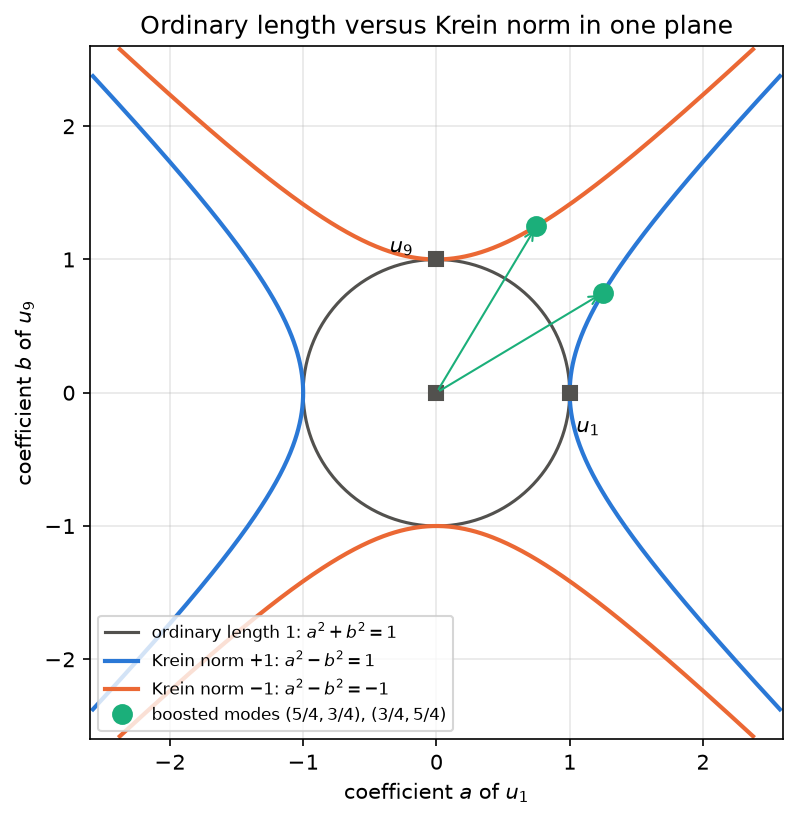

Figure 10b.3 saved as Revision/textbook/figures/10b_3_krein_plane.png


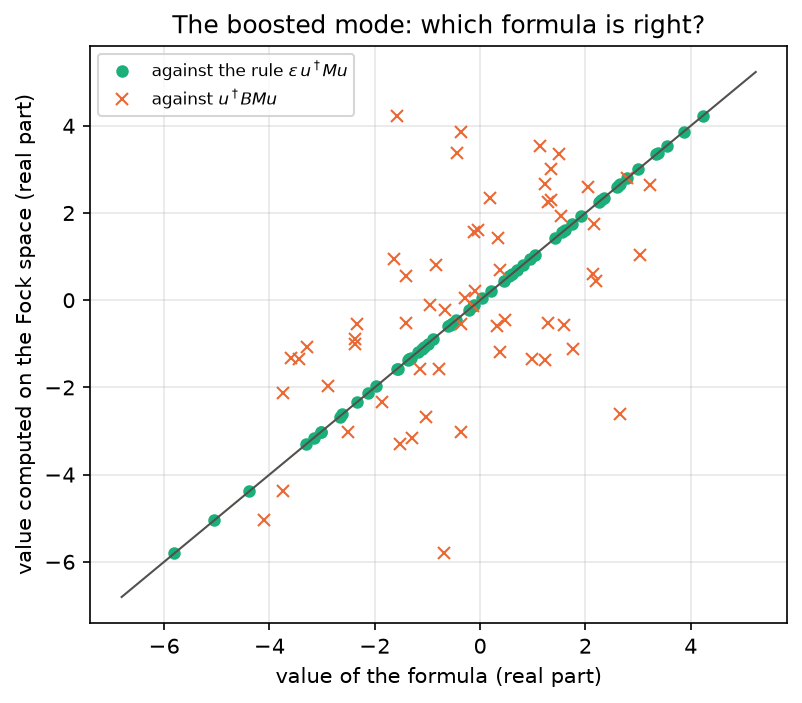

Figure 10b.4 saved as Revision/textbook/figures/10b_4_expectation_rule.png


In [9]:
fig, ax = plt.subplots(figsize=(6.0, 6.0))
angle = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(angle), np.sin(angle), color="#52514e", linewidth=1.5,
        label="ordinary length 1: $a^2 + b^2 = 1$")
t = np.linspace(-1.6, 1.6, 400)
for side in (1, -1):  # the two branches of each hyperbola
    ax.plot(side * np.cosh(t), np.sinh(t), color="#2a78d6", linewidth=2,
            label="Krein norm $+1$: $a^2 - b^2 = 1$" if side == 1 else None)
    ax.plot(np.sinh(t), side * np.cosh(t), color="#eb6834", linewidth=2,
            label="Krein norm $-1$: $a^2 - b^2 = -1$" if side == 1 else None)
ax.plot([0, 1, 0], [1, 0, 0], "s", color="#52514e", markersize=7)
ax.annotate("$u_1$", (1.0, 0.0), xytext=(1.05, -0.3))
ax.annotate("$u_9$", (0.0, 1.0), xytext=(-0.35, 1.05))
ax.plot([1.25, 0.75], [0.75, 1.25], "o", color="#1baf7a", markersize=9,
        label="boosted modes $(5/4, 3/4)$, $(3/4, 5/4)$")
for x_end, y_end in ((1.25, 0.75), (0.75, 1.25)):
    ax.annotate("", xy=(x_end, y_end), xytext=(0, 0),
                arrowprops={"arrowstyle": "->", "color": "#1baf7a"})
ax.set_xlim(-2.6, 2.6)
ax.set_ylim(-2.6, 2.6)
ax.set_aspect("equal")
ax.set_xlabel("coefficient $a$ of $u_1$")
ax.set_ylabel("coefficient $b$ of $u_9$")
ax.set_title("Ordinary length versus Krein norm in one plane")
ax.legend(loc="lower left", fontsize=8)
save_figure(fig, "krein_plane",
            "The plane of the columns $a u_1 + b u_9$ spanned by a mode $u_1$ with "
            "$Bu_1 = u_1$ and a mode $u_9$ with $Bu_9 = -u_9$, both of ordinary "
            "length 1 (horizontal axis $a$, vertical axis $b$, pure numbers). The "
            "grey circle holds the columns of ordinary length 1, $a^2 + b^2 = 1$; "
            "the blue hyperbola those of Krein norm $a^2 - b^2 = +1$, the orange "
            "one those of Krein norm $-1$. The Krein-boosted modes $(5/4, 3/4)$ and "
            "$(3/4, 5/4)$ (green) keep the Krein norms $+1$ and $-1$ but have the "
            "ordinary squared length $34/16$, and they are Krein-orthogonal: "
            "$\\frac{5}{4}\\cdot\\frac{3}{4} - \\frac{3}{4}\\cdot\\frac{5}{4} = 0$.")

fig, ax = plt.subplots(figsize=(6.0, 5.0))
ax.plot(points[:, 1], points[:, 0], "o", color="#1baf7a", markersize=5,
        label="against the rule $\\epsilon\\,u^\\dagger M u$")
ax.plot(points[:, 2], points[:, 0], "x", color="#eb6834", markersize=6,
        label="against $u^\\dagger B M u$")
low, high = points.min() - 1, points.max() + 1
ax.plot([low, high], [low, high], color="#52514e", linewidth=1)
ax.set_xlabel("value of the formula (real part)")
ax.set_ylabel("value computed on the Fock space (real part)")
ax.set_title("The boosted mode: which formula is right?")
ax.legend(loc="upper left", fontsize=8)
save_figure(fig, "expectation_rule",
            "For 60 random complex $16 \\times 16$ matrices $M$: the normalised "
            "expectation value of $\\Psi^\\dagger M\\Psi$ in the Krein-boosted mode, "
            "computed on the Fock space (vertical axis), against the rule "
            "$\\epsilon u^\\dagger Mu$ of the Revision record (green dots) and "
            "against the formula $u^\\dagger BMu$ (orange crosses); horizontal "
            "axis: the value of the formula; real parts, pure numbers. The green "
            "dots lie exactly on the diagonal; the orange crosses do not, because "
            "the boosted mode is not an eigenvector of $B$.")

## 10. Maps that keep the anticommutator; the conjugation of the quantised field

**Linear maps.** If $\Psi' = M\Psi$ with a constant matrix $M$, then
$\{\Psi'_A, \Psi'^\dagger_C\} = \sum_{D,F} M_{AD}M_{CF}^*\{\Psi_D, \Psi^\dagger_F\} =
(MBM^\dagger)_{AC}$. The Revision pairing record lists $MBM^\dagger = \sigma B$ with a
sign $\sigma$ for 17 maps: the chirality $\Gamma$, the eight gammas
$\gamma^{(x_a)}$ and the eight reflections $P_a = \Gamma\gamma^{(x_a)}$. A map with
$\sigma = -1$ turns the canonical rule into its negative: the chirality image
$\Gamma\Psi$ of the pairing theorem T1 carries the Krein metric $-B$ (statement Q1
of the quantum reading), while the mirror map $\gamma^{(x_8)}$ of theorem T2 keeps
$+B$.

**Conjugation of the quantised field.** Charge conjugation is a MATRIX map. For the
quantised field it has the form $\Psi^c = M\Psi^{\dagger T}$, that is
$\Psi^c_A = \sum_C M_{AC}\Psi^\dagger_C$. Then, line by line,

$$\{\Psi^c_A, \Psi^{c\dagger}_C\} = \sum_{D,F} M_{AD}M_{CF}^*\{\Psi^\dagger_D,
\Psi_F\} = \sum_{D,F} M_{AD}B_{FD}M_{CF}^* = (MB^TM^\dagger)_{AC}.$$

$B$ is Hermitian and purely imaginary, so $B^T = B^* = -B$. For $M = I$ (the map
$\Psi \to \Psi^{\dagger T}$, which is not a symmetry here) the result is $B^T = -B$:
the sign of the canonical rule is reversed. For $M = \Gamma$ the result is
$\Gamma B^T\Gamma^\dagger = -\Gamma B\Gamma = +B$, because $\Gamma B\Gamma = -B$
($\Gamma$ anticommutes with the five gammas in $B$, an odd number). So the
conjugation of the quantised field that preserves $\{\Psi, \Psi^\dagger\} = B\delta$
is $\Psi \to \Gamma\Psi^{\dagger T}$, and since $\Gamma$ anticommutes with every
gamma it maps the field of mass $m$ to the field of mass $-m$. The next cell checks
all of this.

In [10]:
pairing = json.loads(repository_file("Revision/pairing/pairing-theory.json")
                     .read_text(encoding="utf-8"))
rows = pairing["data"]["Krein_signs_M_B_Mdagger"]
maps = {"Gamma": Gamma}
for a in range(1, 9):
    maps[f"gamma^x{a}"] = gamma[a]
    maps[f"P_x{a}"] = Gamma @ gamma[a]  # the reflection P_a = Gamma gamma^(x_a)
signs, agree = [], True
for row in rows:
    M = maps[row["map"]]
    transformed = M @ B @ M.conj().T  # M B M^dagger
    sign = (1 if np.array_equal(transformed, B)
            else -1 if np.array_equal(transformed, -B) else 0)
    signs.append(sign)
    agree = agree and sign == row["sign"]
names = [row["map"] for row in rows]  # the names of the 17 maps in the record
say("map: sign sigma in M B M^dagger = sigma B")
say(", ".join(f"{name}: {s:+d}" for name, s in zip(names, signs)))
check_record(agree and len(rows) == 17,
             "the Krein signs of all 17 recorded maps are reproduced",
             record="Revision/pairing/pairing-theory.json, data "
                    "Krein_signs_M_B_Mdagger")
check_record(np.array_equal(Gamma @ B @ Gamma.T, -B),
             "the chirality image Gamma Psi carries the Krein metric -B",
             record="Revision/pairing/reports/python-pairing.json, check "
                    "Q.image_krein_metric")
check_record(np.array_equal(gamma[8] @ B @ gamma[8].T, B),
             "the mirror image gamma^(x8) Psi keeps +B",
             record="Revision/pairing/reports/python-pairing.json, check "
                    "Q.T2_image_keeps_B")

identity = np.eye(16)
conjugation_identity = identity @ B.T @ identity.conj().T  # M = I
conjugation_gamma = Gamma @ B.T @ Gamma.conj().T  # M = Gamma
check(np.array_equal(B.T, -B), "B^T = -B (B is Hermitian and purely imaginary)")
check_record(np.array_equal(conjugation_gamma, B)
             and np.array_equal(conjugation_identity, -B),
             "Psi -> Gamma Psi^(dagger T) keeps B; with M = I one gets -B",
             record="Revision/lead_checks/reports/charge-conjugation-and-u1.json, "
                    "check quantum_charge_conjugation_unitary_type")
mass_reversed = all(np.array_equal(Gamma @ gamma[a] @ Gamma, -gamma[a])
                    for a in range(1, 9))
check(mass_reversed, "Gamma anticommutes with every gamma: the conjugation reverses m")

map: sign sigma in M B M^dagger = sigma B
Gamma: -1, gamma^x1: +1, gamma^x2: +1, gamma^x3: +1, gamma^x4: +1, gamma^x5: -1,
    gamma^x6: -1, gamma^x7: -1, gamma^x8: +1, P_x1: -1, P_x2: -1, P_x3: -1, P_x4: -1,
    P_x5: +1, P_x6: +1, P_x7: +1, P_x8: -1
PASS the Krein signs of all 17 recorded maps are reproduced
     reproduces Revision/pairing/pairing-theory.json, data Krein_signs_M_B_Mdagger
PASS the chirality image Gamma Psi carries the Krein metric -B
     reproduces Revision/pairing/reports/python-pairing.json, check Q.image_krein_metric
PASS the mirror image gamma^(x8) Psi keeps +B
     reproduces Revision/pairing/reports/python-pairing.json, check Q.T2_image_keeps_B
PASS B^T = -B (B is Hermitian and purely imaginary)
PASS Psi -> Gamma Psi^(dagger T) keeps B; with M = I one gets -B
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    quantum_charge_conjugation_unitary_type
PASS Gamma anticommutes with every gamma: the conjugation reverses m


The next cell draws the signs as a bar chart: one bar per map, $+1$ (the map keeps
the canonical rule) or $-1$ (it reverses it), and, separately, the two candidate
conjugations of the quantised field.

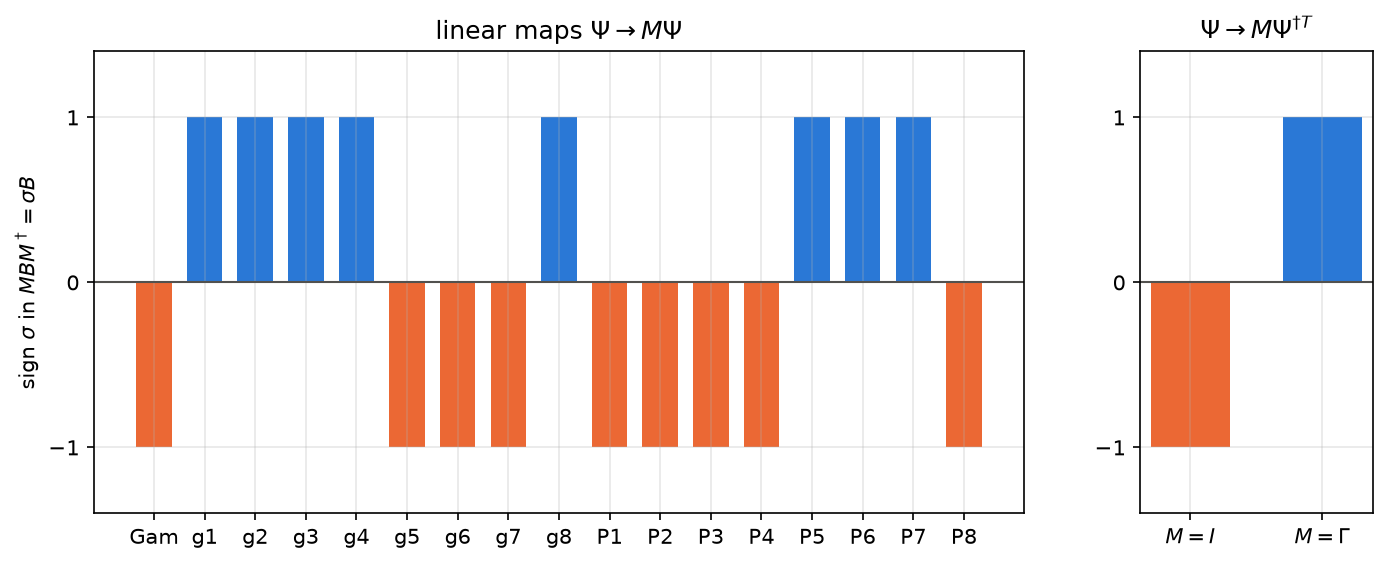

Figure 10b.5 saved as Revision/textbook/figures/10b_5_krein_signs.png


In [11]:
labels = [row["map"].replace("gamma^x", "g").replace("P_x", "P") for row in rows]
labels = [lab if lab != "Gamma" else "Gam" for lab in labels]
colours = ["#2a78d6" if s > 0 else "#eb6834" for s in signs]
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0),
                         gridspec_kw={"width_ratios": [4, 1]})
axes[0].bar(range(len(signs)), signs, color=colours, width=0.7)
axes[0].set_xticks(range(len(signs)), labels)
axes[0].axhline(0, color="#52514e", linewidth=1)
axes[0].set_ylim(-1.4, 1.4)
axes[0].set_yticks([-1, 0, 1])
axes[0].set_ylabel("sign $\\sigma$ in $M B M^\\dagger = \\sigma B$")
axes[0].set_title("linear maps $\\Psi \\to M\\Psi$")
conjugation_signs = [-1, 1]  # M = I gives -B, M = Gamma gives +B
axes[1].bar([0, 1], conjugation_signs, color=["#eb6834", "#2a78d6"], width=0.6)
axes[1].set_xticks([0, 1], ["$M = I$", "$M = \\Gamma$"])
axes[1].axhline(0, color="#52514e", linewidth=1)
axes[1].set_ylim(-1.4, 1.4)
axes[1].set_yticks([-1, 0, 1])
axes[1].set_title("$\\Psi \\to M\\Psi^{\\dagger T}$")
save_figure(fig, "krein_signs",
            "Left: the sign $\\sigma$ (vertical axis) with $MBM^\\dagger = \\sigma B$ "
            "for the 17 matrix maps of the Revision pairing record (horizontal "
            "axis: Gam is the chirality $\\Gamma$, g1 to g8 the gammas "
            "$\\gamma^{(x_1)}$ to $\\gamma^{(x_8)}$, P1 to P8 the reflections "
            "$\\Gamma\\gamma^{(x_a)}$); blue bars keep the canonical rule "
            "$\\{\\Psi, \\Psi^\\dagger\\} = B\\delta$, orange bars reverse it to "
            "$-B$. Right: the two candidate conjugations $\\Psi \\to "
            "M\\Psi^{\\dagger T}$ of the quantised field, with the sign of "
            "$MB^TM^\\dagger$: only $M = \\Gamma$ keeps $+B$, and it reverses the "
            "mass.")

## 11. The last check

The last cell checks that all five figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [12]:
for name in ("10b_1_positivity.png", "10b_2_krein_norms_random.png",
             "10b_3_krein_plane.png", "10b_4_expectation_rule.png",
             "10b_5_krein_signs.png"):
    check(output_file(f"{FIGURE_FOLDER}/{name}").is_file(),
          f"the figure file {name} exists")
all_checks_passed()

PASS the figure file 10b_1_positivity.png exists
PASS the figure file 10b_2_krein_norms_random.png exists
PASS the figure file 10b_3_krein_plane.png exists
PASS the figure file 10b_4_expectation_rule.png exists
PASS the figure file 10b_5_krein_signs.png exists
ALL 24 CHECKS PASSED (notebook 10b)


## 12. What this notebook showed

- PROVED (exactly): the time-derivative term of the Lagrangian is
  $\Psi^\dagger K\partial_4\Psi$ with $K = i\cos z\,B$, and the canonical rule
  $\{\Psi, \Psi^\dagger\} = iK^{-1}\delta^7 = B\delta^7/\cos z$.
- CHECKED on an explicit fermionic Fock space (16 modes, 65536 patterns, of which
  only the needed ones are stored): the anticommutation relations, the canonical
  rule with $\Psi^\dagger = \chi B$, and the Heisenberg equation $i\partial_4\Psi =
  h\Psi$ for a plane wave, the classical wave equation of the field.
- PROVED (and checked on the Fock space): because $B$ has the eigenvalue $-1$, the
  canonical conjugate $\Psi^\dagger$ cannot be the Hilbert adjoint of $\Psi$ in a
  space with a positive inner product. The canonical rule defines a Krein space
  with fundamental symmetry $B$; in a positive Hilbert space the canonical
  conjugate is $\Psi^\dagger = \chi B$, with $\chi$ the Hilbert adjoint.
- CHECKED: the Krein-Fock realisation with modes of Krein norm $\pm1$ (including a
  Krein-boosted pair) gives the same rule, and the expectation value in a mode is
  $\epsilon_n u_n^\dagger M u_n$, which equals $u_n^\dagger BMu_n$ only when the mode
  is an eigenvector of $B$.
- PROVED: the chirality image $\Gamma\Psi$ carries $-B$, the mirror image
  $\gamma^{(x_8)}\Psi$ keeps $+B$ (all 17 recorded signs reproduced); the
  conjugation of the quantised field that preserves the canonical rule is the
  MATRIX map $\Psi \to \Gamma\Psi^{\dagger T}$, which reverses the mass; the map
  with $M = I$ would reverse the sign of the rule.
- NOT shown here: a positive state space for the whole field. The next notebook
  builds the positive Fock space of the good sector, one momentum at a time.